# AAAIM Evaluation Test - UniProt

This notebook tests both single model evaluation and batch evaluation of multiple models.

In [5]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import logging

# Add the project root to the Python path
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

# Import AAAIM functions
from core import annotate_model, curate_model
from utils.evaluation import (
    evaluate_single_model,
    evaluate_models_in_folder,
    print_evaluation_results,
    compare_results
)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# LLM configuration
# llm_model = "meta-llama/llama-3.3-70b-instruct:free"  # or "gpt-4o-mini"
llm_model = "Llama-3.3-70B-Instruct"

# Evaluation parameters
max_entities_per_model = 10  # Limit entities per model for testing
num_models_to_test = 5  # Number of models to test in batch evaluation

# Entity and database configuration
entity_type = "protein"
database = "uniprot"

output_dir = "./results/"  # Output directory for results

## BioModels
### Single Model Evaluation

Evaluation of a single model with existing annotations.

In [2]:
test_model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/BIOMD0000000019.xml"
tax_id = 9606
# Check if test model exist

if os.path.exists(test_model_file):
    print(f"✓ Test model found: {test_model_file}")
else:
    print(f"✗ Test model not found: {test_model_file}")

✓ Test model found: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/BIOMD0000000019.xml


In [3]:
# Test with a single model
recommendations_df, metrics = annotate_model(
    model_file=test_model_file,
    llm_model=llm_model,
    max_entities=max_entities_per_model,
    entity_type=entity_type,
    database=database,
    tax_id=tax_id
)

2025-08-19 01:11:02,095 - INFO - Starting annotation for model: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/BIOMD0000000019.xml
2025-08-19 01:11:02,095 - INFO - Using LLM model: Llama-3.3-70B-Instruct
2025-08-19 01:11:02,096 - INFO - Using method: direct for database search
2025-08-19 01:11:02,096 - INFO - Entity type: protein, Database: uniprot
2025-08-19 01:11:02,096 - INFO - Using organism-specific search for tax_id: 9606
2025-08-19 01:11:02,096 - INFO - >>>Step 1: Getting species from model...<<<
2025-08-19 01:11:02,126 - INFO - Found 100 species in model
2025-08-19 01:11:02,155 - INFO - Found 17 entities with existing annotations
2025-08-19 01:11:02,155 - INFO - Selected 10 entities for annotation
2025-08-19 01:11:02,156 - INFO - >>>Step 2: Extracting model context...<<<
2025-08-19 01:11:02,297 - INFO - Extracted context for model: Schoeberl2002 - EGF MAPK
2025-08-19 01:11:02,297 - INFO - >>>Step 3: Querying LLM (Llama-3.3-70B-Instruct)...<<<
2025-08-19 01:11:08,462 - INFO

In [4]:
recommendations_df

,file,type,id,display_name,annotation,annotation_label,match_score,existing,update_annotation,qualifier
0,BIOMD0000000019.xml,protein,x1,EGF,UNIPROT:P01133,EGF,0.333333,0,ignore,is
1,BIOMD0000000019.xml,protein,x2,EGFR,UNIPROT:P00533,EGFR,1.000000,0,add,is
2,BIOMD0000000019.xml,protein,x3,EGF-EGFR,UNIPROT:P00533,EGFR,1.000000,1,keep,hasVersion
3,BIOMD0000000019.xml,protein,x4,EGF-EGFR^2,UNIPROT:P00533,EGFR,1.000000,1,keep,hasVersion
4,BIOMD0000000019.xml,protein,x5,EGF-EGFR*^2,UNIPROT:P00533,EGFR,1.000000,1,keep,hasVersion
5,BIOMD0000000019.xml,protein,x6,EGFRi,UNIPROT:P00533,EGFR,1.000000,1,keep,isVersionOf
6,BIOMD0000000019.xml,protein,x7,EGF-EGFR*^2-GAP-Grb2-Prot,UNIPROT:P62993,GRB2,0.333333,1,keep,hasVersion
7,BIOMD0000000019.xml,protein,x8,EGF-EGFRi*^2,UNIPROT:P00533,EGFR,1.000000,1,keep,hasVersion
8,BIOMD0000000019.xml,protein,x9,Proti,,x9,0.000000,0,ignore,is
9,BIOMD0000000019.xml,protein,x10,EGF-EGFRi,UNIPROT:P00533,EGFR,1.000000,1,keep,hasVersion


In [5]:
metrics

{'total_entities': 10,
 'entities_with_predictions': 9,
 'annotation_rate': 0.9,
 'total_predictions': 9,
 'matches': 7,
 'accuracy': 0.7,
 'total_time': 6.628072023391724,
 'llm_time': 6.021944046020508,
 'search_time': 0.2393207550048828}

In [3]:
# curation: look at existing annotations
recommendations_df, metrics = curate_model(
    model_file=test_model_file,
    llm_model=llm_model,
    max_entities=max_entities_per_model,
    entity_type=entity_type,
    database=database,
    tax_id=tax_id
)

2025-08-19 01:08:24,962 - INFO - Starting curation for model: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/BIOMD0000000019.xml
2025-08-19 01:08:24,963 - INFO - Using LLM model: Llama-3.3-70B-Instruct
2025-08-19 01:08:24,963 - INFO - Using method: direct for database search
2025-08-19 01:08:24,963 - INFO - Entity type: protein, Database: uniprot
2025-08-19 01:08:24,963 - INFO - Using organism-specific search for tax_id: 9606
2025-08-19 01:08:24,964 - INFO - >>>Step 1: Finding existing annotations...<<<
2025-08-19 01:08:24,994 - INFO - Found 17 entities with existing annotations
2025-08-19 01:08:24,994 - INFO - Selected 10 entities for curation
2025-08-19 01:08:24,995 - INFO - >>>Step 2: Extracting model context...<<<
2025-08-19 01:08:25,133 - INFO - Extracted context for model: Schoeberl2002 - EGF MAPK
2025-08-19 01:08:25,133 - INFO - >>>Step 3: Querying LLM ({llm_model})...<<<
2025-08-19 01:08:29,045 - INFO - HTTP Request: POST https://api.llama.com/compat/v1/chat/completions "H

In [4]:
recommendations_df

,file,type,id,display_name,annotation,annotation_label,match_score,existing,update_annotation,qualifier
0,BIOMD0000000019.xml,protein,x10,EGF-EGFRi,UNIPROT:P01133,EGF,NaN,1,keep,hasVersion
1,BIOMD0000000019.xml,protein,x10,EGF-EGFRi,UNIPROT:P00533,EGFR,1.000000,1,keep,hasVersion
2,BIOMD0000000019.xml,protein,x14,GAP,UNIPROT:P20936,RASA1,0.666667,1,keep,isVersionOf
3,BIOMD0000000019.xml,protein,x22,Grb2,UNIPROT:P62993,GRB2,0.666667,1,keep,isVersionOf
4,BIOMD0000000019.xml,protein,x22,Grb2,UNIPROT:Q5FYA8,ARSH,0.333333,0,ignore,is
5,BIOMD0000000019.xml,protein,x24,Sos,UNIPROT:Q07889,SOS1,0.333333,1,keep,isVersionOf
6,BIOMD0000000019.xml,protein,x26,x26,UNIPROT:P01112,HRAS,NaN,1,keep,hasPart
7,BIOMD0000000019.xml,protein,x28,x28,UNIPROT:P01112,HRAS,NaN,1,keep,hasPart
8,BIOMD0000000019.xml,protein,x3,EGF-EGFR,UNIPROT:P01133,EGF,NaN,1,keep,hasVersion
9,BIOMD0000000019.xml,protein,x3,EGF-EGFR,UNIPROT:P00533,EGFR,1.000000,1,keep,hasVersion


In [6]:
# Test using utils evaluation function
result_df = evaluate_single_model(
    model_file=test_model_file,
    tax_id=tax_id,
    llm_model=llm_model,
    max_entities=max_entities_per_model,
    entity_type=entity_type,
    database=database,
    save_llm_results=False,
    output_dir=output_dir
)

2025-08-19 01:11:43,046 - INFO - Evaluating model: BIOMD0000000019.xml
2025-08-19 01:11:43,047 - INFO - Using organism-specific search for tax_id: 9606
2025-08-19 01:11:43,101 - INFO - Evaluating 10 entities in BIOMD0000000019.xml
2025-08-19 01:11:50,075 - INFO - HTTP Request: POST https://api.llama.com/compat/v1/chat/completions "HTTP/1.1 200 OK"


In [7]:
result_df

,model,species_id,display_name,synonyms_LLM,reason,exist_annotation_id,exist_annotation_name,predictions,predictions_names,match_score,...,precision_formula,recall_exact,precision_exact,accuracy,total_time,llm_time,query_time,tax_id,tax_name,qualifier
0,BIOMD0000000019.xml,x3,EGF-EGFR,"[EGFR, ERBB1, HER1]","The model is an EGF MAPK pathway, and the disp...","[P01133, P00533]","EGF, EGFR",[P00533],EGFR,[1.0],...,0,0.50,1.0,1,6.803192,6.682817,0.120375,9606,None,"hasVersion, hasVersion"
1,BIOMD0000000019.xml,x4,EGF-EGFR^2,"[EGFR, ERBB1, HER1]","The model is an EGF MAPK pathway, and the disp...","[P01133, P00533]","EGF, EGFR",[P00533],EGFR,[1.0],...,0,0.50,1.0,1,6.803192,6.682817,0.120375,9606,None,"hasVersion, hasVersion"
2,BIOMD0000000019.xml,x5,EGF-EGFR*^2,"[EGFR, ERBB1, HER1]","The model is an EGF MAPK pathway, and the disp...","[P00533, P01133]","EGFR, EGF",[P00533],EGFR,[1.0],...,0,0.50,1.0,1,6.803192,6.682817,0.120375,9606,None,"hasVersion, hasVersion"
3,BIOMD0000000019.xml,x6,EGFRi,"[EGFR, ERBB1, HER1]","The model is an EGF MAPK pathway, and the disp...",[P00533],EGFR,[P00533],EGFR,[1.0],...,0,1.00,1.0,1,6.803192,6.682817,0.120375,9606,None,isVersionOf
4,BIOMD0000000019.xml,x7,EGF-EGFR*^2-GAP-Grb2-Prot,"[GRB2, GROWTH FACTOR RECEPTOR-BOUND PROTEIN 2,...","The model is an EGF MAPK pathway, and the disp...","[P20936, P62993, P00533, P01133]","RASA1, GRB2, EGFR, EGF","[P62993, Q5FYA8]","GRB2, ARSH","[0.6666666666666666, 0.3333333333333333]",...,0,0.25,0.5,1,6.803192,6.682817,0.120375,9606,None,"hasVersion, hasVersion, hasVersion, hasVersion"
5,BIOMD0000000019.xml,x8,EGF-EGFRi*^2,"[EGFR, ERBB1, HER1]","The model is an EGF MAPK pathway, and the disp...","[P00533, P01133]","EGFR, EGF",[P00533],EGFR,[1.0],...,0,0.50,1.0,1,6.803192,6.682817,0.120375,9606,None,"hasVersion, hasVersion"
6,BIOMD0000000019.xml,x10,EGF-EGFRi,"[EGFR, ERBB1, HER1]","The model is an EGF MAPK pathway, and the disp...","[P01133, P00533]","EGF, EGFR",[P00533],EGFR,[1.0],...,0,0.50,1.0,1,6.803192,6.682817,0.120375,9606,None,"hasVersion, hasVersion"
7,BIOMD0000000019.xml,x14,GAP,"[GAP, GTPASE ACTIVATING PROTEIN, RASA1]","The model is an EGF MAPK pathway, and the disp...",[P20936],RASA1,[P20936],RASA1,[0.6666666666666666],...,0,1.00,1.0,1,6.803192,6.682817,0.120375,9606,None,isVersionOf
8,BIOMD0000000019.xml,x22,Grb2,"[GRB2, GROWTH FACTOR RECEPTOR-BOUND PROTEIN 2,...","The model is an EGF MAPK pathway, and the disp...",[P62993],GRB2,"[P62993, Q5FYA8]","GRB2, ARSH","[0.6666666666666666, 0.3333333333333333]",...,0,1.00,0.5,1,6.803192,6.682817,0.120375,9606,None,isVersionOf
9,BIOMD0000000019.xml,x24,Sos,"[SOS1, SON OF SEVENLESS, GDP-DISSOCIATION INHI...","The model is an EGF MAPK pathway, and the disp...",[Q07889],SOS1,[Q07889],SOS1,[0.3333333333333333],...,0,1.00,1.0,1,6.803192,6.682817,0.120375,9606,None,isVersionOf


### Batch Model Evaluation
Test the evaluation of multiple models in a directory.

In [6]:
model_dir = '/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/'

# Check if model directory exists
if os.path.exists(model_dir):
    model_files = [f for f in os.listdir(model_dir) if f.endswith('.xml')]
    print(f"✓ Model directory found: {model_dir}")
    print(f"  - Found {len(model_files)} SBML files")
    # print(f"  - Will test first {min(num_models_to_test, len(model_files))} models")

✓ Model directory found: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/
  - Found 1063 SBML files


In [ ]:
# Run batch evaluation 
batch_results_df = evaluate_models_in_folder(
    model_dir=model_dir,
    # num_models=20,
    llm_model=llm_model,
    entity_type=entity_type,
    database=database,
    save_llm_results=True,
    output_dir=output_dir,
    output_file="biomd_uniprot_direct_llama-3_top3_9606_with_reaction.csv",
    start_at=1,
    tax_id = 9606
)

In [8]:
print_evaluation_results(output_dir + "biomd_uniprot_direct_llama-3_top3_9606_with_reaction.csv", ref_results_csv = None)

Showing all results
Number of models assessed: 310
Number of models with predictions: 309
Number of annotations evaluated: 5311
Average accuracy (per model): 0.72
Ave. recall (formula): 0.00
Ave. precision (formula): 0.00
Ave. recall (exact): 0.67
Ave. precision (exact): 0.48
Average accuracy (per species): 0.67
Ave. recall (formula, per species): 0.00
Ave. precision (formula, per species): 0.00
Ave. recall (exact, per species): 0.59
Ave. precision (exact, per species): 0.46
Ave. total time (per model): 9.33
Ave. total time (per element, per model): 0.54
Ave. LLM time (per model): 9.16
Ave. LLM time (per element, per model): 0.53
Average number of predictions per species: 1.67


In [10]:
print_evaluation_results(output_dir + "biomd_uniprot_direct_llama-3_top3_9606_without_reaction.csv", ref_results_csv = None)

Showing all results
Number of models assessed: 310
Number of models with predictions: 308
Number of annotations evaluated: 5311
Average accuracy (per model): 0.73
Ave. recall (formula): 0.00
Ave. precision (formula): 0.00
Ave. recall (exact): 0.68
Ave. precision (exact): 0.49
Average accuracy (per species): 0.70
Ave. recall (formula, per species): 0.00
Ave. precision (formula, per species): 0.00
Ave. recall (exact, per species): 0.61
Ave. precision (exact, per species): 0.49
Ave. total time (per model): 9.31
Ave. total time (per element, per model): 0.54
Ave. LLM time (per model): 9.15
Ave. LLM time (per element, per model): 0.53
Average number of predictions per species: 1.76


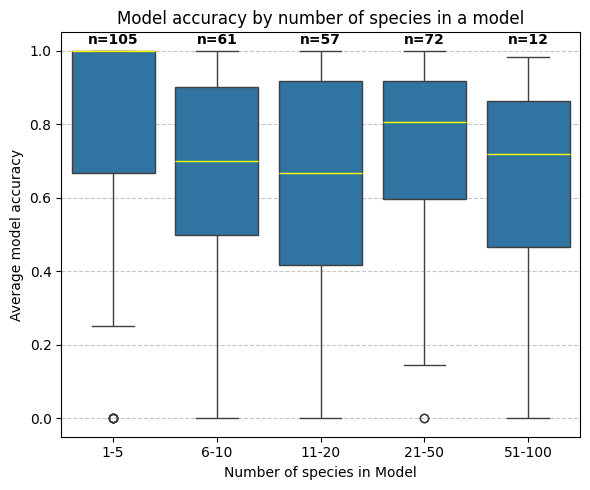

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
results_llama = pd.read_csv('results/biomd_uniprot_direct_llama-3_top3_9606.csv')
# Group models by number of species and calculate accuracy statistics
model_species_count = results_llama.groupby('model').size().reset_index(name='species_count')
model_accuracy = results_llama.groupby('model')['accuracy'].mean().reset_index()

# Merge the two dataframes
model_stats = pd.merge(model_species_count, model_accuracy, on='model')

# Create bins for species count to make the box plot more readable
bins = [0, 5, 10, 20, 50, 100]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100']
model_stats['species_count_bin'] = pd.cut(model_stats['species_count'], bins=bins, labels=labels)

# Count number of models in each bin
bin_counts = model_stats['species_count_bin'].value_counts().reindex(labels, fill_value=0)

# Create the box plot
plt.figure(figsize=(6, 5))
ax = sns.boxplot(x='species_count_bin', y='accuracy', data=model_stats, medianprops={"color": "yellow", "linewidth": 1})

# Add counts above each box
for i, label in enumerate(labels):
    count = bin_counts[label]
    ax.text(i, 1.01, f'n={count}', ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

plt.title('Model accuracy by number of species in a model')
plt.xlabel('Number of species in Model')
plt.ylabel('Average model accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'biomd_uniprot_direct_llama-3_top3_9606.png'), dpi=300, bbox_inches='tight')
plt.show()

## BioDivine
### Single Model Evaluation

In [4]:
test_model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/218_TCA-CYCLE_source.sbml"
tax_id = 9606
# Check if test model exist

if os.path.exists(test_model_file):
    print(f"✓ Test model found: {test_model_file}")
else:
    print(f"✗ Test model not found: {test_model_file}")

✓ Test model found: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/218_TCA-CYCLE_source.sbml


In [3]:
# Test with a single model
recommendations_df, metrics = annotate_model(
    model_file=test_model_file,
    llm_model=llm_model,
    entity_type=entity_type,
    database=database,
    tax_id=tax_id
)

2025-08-18 15:25:00,918 - INFO - Starting annotation for model: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/119_JNK-PATHWAY_source.sbml
2025-08-18 15:25:00,919 - INFO - Using LLM model: Llama-3.3-70B-Instruct
2025-08-18 15:25:00,919 - INFO - Using method: direct for database search
2025-08-18 15:25:00,919 - INFO - Entity type: protein, Database: uniprot
2025-08-18 15:25:00,920 - INFO - Using organism-specific search for tax_id: 9606
2025-08-18 15:25:00,920 - INFO - >>>Step 1: Getting species from model...<<<
2025-08-18 15:25:00,929 - INFO - Found 19 species in model
2025-08-18 15:25:00,939 - INFO - Found 4 entities with existing annotations
2025-08-18 15:25:00,939 - INFO - Annotate all 19 entities
2025-08-18 15:25:00,939 - INFO - >>>Step 2: Extracting model context...<<<
2025-08-18 15:25:00,970 - INFO - Extracted context for model: model_id
2025-08-18 15:25:00,970 - INFO - >>>Step 3: Querying LLM (Llama-3.3-70B-Instruct)...<<<
2025-08-18 15:25:26,233 - INFO - HTTP Request: POST

In [5]:
result_df = evaluate_single_model(
    model_file=test_model_file,
    tax_id=tax_id,
    llm_model=llm_model,
    entity_type=entity_type,
    database=database,
    save_llm_results=False,
    output_dir=output_dir
)

2025-08-18 15:37:24,641 - INFO - Evaluating model: 218_TCA-CYCLE_source.sbml
2025-08-18 15:37:24,642 - INFO - Using organism-specific search for tax_id: 9606
2025-08-18 15:37:24,702 - INFO - Evaluating 23 entities in 218_TCA-CYCLE_source.sbml


Existing annotations: {'csa1916': ['Q96I99', 'P53597'], 'csa1897': ['P40926'], 'csa1919': ['P07954'], 'csa1898': ['Q9P2J9'], 'csa1902': ['P48735'], 'csa1899': ['P53597', 'Q9P2R7'], 'csa1914': ['O95563', 'Q9Y5U8'], 'csa1949': ['P10515', 'O00330'], 'csa1901': ['Q9P0J1'], 'csa1921': ['Q15119', 'Q15120', 'Q16654', 'Q15118'], 'csa1895': ['P10515', 'O00330'], 'csa1896': ['P50213', 'P51553', 'O43837'], 'sa11962': ['P00367'], 'sa12216': ['Q9H9P8'], 'sa11979': ['P11498'], 'sa11955': ['Q99798'], 'sa11881': ['Q8N465'], 'sa11901': ['Q9NUB1'], 'sa11950': ['O75390'], 'sa11987': ['Q8IWW8'], 'sa11944': ['P05091'], 'sa11867': ['Q9NTG7'], 'sa12293': ['P50583']}


2025-08-18 15:37:38,905 - INFO - HTTP Request: POST https://api.llama.com/compat/v1/chat/completions "HTTP/1.1 200 OK"


In [6]:
result_df

,model,species_id,display_name,synonyms_LLM,reason,exist_annotation_id,exist_annotation_name,predictions,predictions_names,match_score,recall_formula,precision_formula,recall_exact,precision_exact,accuracy,total_time,llm_time,query_time,tax_id,tax_name
0,218_TCA-CYCLE_source.sbml,csa1916,Succinyl-CoA_space_ligase_complex_mitochondria...,"[SUCLG1, SUCLG2, SUCLA2]",Most of the proteins are matched based on thei...,"[Q96I99, P53597]","SUCLG2, SUCLG1","[P53597, Q96I99, Q9P2R7]","SUCLG1, SUCLG2, SUCLA2","[0.3333333333333333, 0.3333333333333333, 0.333...",0,0,1.0,0.666667,1,14.370185,13.910346,0.459839,9606,None
1,218_TCA-CYCLE_source.sbml,csa1897,malate_space_dehydrogenase_space_2_complex,"[MDH2, MDH1B, MDH1A]",Most of the proteins are matched based on thei...,[P40926],MDH2,"[P40926, Q5I0G3]","MDH2, MDH1B","[0.3333333333333333, 0.3333333333333333]",0,0,1.0,0.500000,1,14.370185,13.910346,0.459839,9606,None
2,218_TCA-CYCLE_source.sbml,csa1919,fumarate_space_hydratase_complex,"[FH, Fumarase, FH1]",Most of the proteins are matched based on thei...,[P07954],FH,"[P07954, O75369]","FH, FLNB","[0.6666666666666666, 0.3333333333333333]",0,0,1.0,0.500000,1,14.370185,13.910346,0.459839,9606,None
3,218_TCA-CYCLE_source.sbml,csa1898,PDP2:PDPR_complex,"[PDP2, PDK3, PDPR]",Most of the proteins are matched based on thei...,[Q9P2J9],PDP2,"[Q8NCN5, Q9P2J9, Q15120]","PDPR, PDP2, PDK3","[0.6666666666666666, 0.3333333333333333, 0.333...",0,0,1.0,0.333333,1,14.370185,13.910346,0.459839,9606,None
4,218_TCA-CYCLE_source.sbml,csa1902,isocitrate_space_dehydrogenase_complex,"[IDH3A, IDH3B, IDH3G]",Most of the proteins are matched based on thei...,[P48735],IDH2,"[P50213, O43837, P51553]","IDH3A, IDH3B, IDH3G","[0.3333333333333333, 0.3333333333333333, 0.333...",0,0,0.0,0.000000,0,14.370185,13.910346,0.459839,9606,None
5,218_TCA-CYCLE_source.sbml,csa1899,Succinyl-CoA_space_ligase_complex_mitochondria...,"[SUCLG1, SUCLG2, SUCLA2]",Most of the proteins are matched based on thei...,"[P53597, Q9P2R7]","SUCLG1, SUCLA2","[P53597, Q96I99, Q9P2R7]","SUCLG1, SUCLG2, SUCLA2","[0.3333333333333333, 0.3333333333333333, 0.333...",0,0,1.0,0.666667,1,14.370185,13.910346,0.459839,9606,None
6,218_TCA-CYCLE_source.sbml,csa1914,mitochondrial_space_pyruvate_space_carrier_com...,"[MPC1, MPC2, SLC25A51]",Most of the proteins are matched based on thei...,"[O95563, Q9Y5U8]","MPC2, MPC1","[Q9Y5U8, O95563, Q9H1U9]","MPC1, MPC2, SLC25A51","[0.3333333333333333, 0.3333333333333333, 0.333...",0,0,1.0,0.666667,1,14.370185,13.910346,0.459839,9606,None
7,218_TCA-CYCLE_source.sbml,csa1949,pyruvate_space_dehydrogenase_space_complex_com...,"[PDHA1, PDHB, PDHX]",Most of the proteins are matched based on thei...,"[P10515, O00330]","DLAT, PDHX","[P08559, P11177, O00330]","PDHA1, PDHB, PDHX","[0.3333333333333333, 0.3333333333333333, 0.333...",0,0,0.5,0.333333,1,14.370185,13.910346,0.459839,9606,None
8,218_TCA-CYCLE_source.sbml,csa1901,PDP1:PDPR_complex,"[PDP1, PDK1, PDPR]",Most of the proteins are matched based on thei...,[Q9P0J1],PDP1,"[Q8NCN5, Q9P0J1, Q8IY26]","PDPR, PDP1, PLPP6","[0.6666666666666666, 0.3333333333333333, 0.333...",0,0,1.0,0.333333,1,14.370185,13.910346,0.459839,9606,None
9,218_TCA-CYCLE_source.sbml,csa1921,PDK_space_isoforms_complex,"[PDK1, PDK2, PDK3]",Most of the proteins are matched based on thei...,"[Q15119, Q15120, Q16654, Q15118]","PDK2, PDK3, PDK4, PDK1","[Q15118, O15530, Q15119]","PDK1, PDPK1, PDK2","[0.3333333333333333, 0.3333333333333333, 0.333...",0,0,0.5,0.666667,1,14.370185,13.910346,0.459839,9606,None


### Batch Model Evaluation

In [5]:
model_dir = '/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/'

# Check if model directory exists
if os.path.exists(model_dir):
    model_files = [f for f in os.listdir(model_dir) if f.endswith('.sbml')]
    print(f"✓ Model directory found: {model_dir}")
    print(f"  - Found {len(model_files)} SBML files")

✓ Model directory found: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/
  - Found 190 SBML files


In [ ]:
# Run batch evaluation 
batch_results_df = evaluate_models_in_folder(
    model_dir=model_dir,
    # num_models=100,
    llm_model=llm_model,
    top_k=3,
    entity_type=entity_type,
    database=database,
    save_llm_results=True,
    output_dir=output_dir,
    output_file="biodivine_uniprot_direct_llama-3_top5_9606.csv",
    start_at=1,
    tax_id = 9606
)

In [ ]:
print_evaluation_results(output_dir + "biodivine_uniprot_direct_llama-3_top3_9606.csv", ref_results_csv = None)

Showing all results
Number of models assessed: 16
Number of models with predictions: 16
Number of annotations evaluated: 634
Average accuracy (per model): 0.91
Ave. recall (formula): 0.00
Ave. precision (formula): 0.00
Ave. recall (exact): 0.89
Ave. precision (exact): 0.65
Average accuracy (per species): 0.94
Ave. recall (formula, per species): 0.00
Ave. precision (formula, per species): 0.00
Ave. recall (exact, per species): 0.91
Ave. precision (exact, per species): 0.66
Ave. total time (per model): 19.09
Ave. total time (per element, per model): 0.48
Ave. LLM time (per model): 18.72
Ave. LLM time (per element, per model): 0.47
Average number of predictions per species: 1.85


In [ ]:
print_evaluation_results(output_dir + "biodivine_uniprot_direct_llama-3_top5_9606.csv", ref_results_csv = None)

Showing all results
Number of models assessed: 16
Number of models with predictions: 16
Number of annotations evaluated: 634
Average accuracy (per model): 0.92
Ave. recall (formula): 0.00
Ave. precision (formula): 0.00
Ave. recall (exact): 0.88
Ave. precision (exact): 0.65
Average accuracy (per species): 0.94
Ave. recall (formula, per species): 0.00
Ave. precision (formula, per species): 0.00
Ave. recall (exact, per species): 0.91
Ave. precision (exact, per species): 0.67
Ave. total time (per model): 22.02
Ave. total time (per element, per model): 0.56
Ave. LLM time (per model): 21.66
Ave. LLM time (per element, per model): 0.55
Average number of predictions per species: 1.86


## Functions test

In [2]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import logging
import libsbml

# Add the project root to the Python path
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

# Import AAAIM functions
from core import annotate_model, curate_model, model_info

In [3]:
model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/BIOMD0000000019.xml"
entity_type = "protein"
species_ids = model_info.get_all_species_ids(model_file, entity_type)
print(species_ids)
model_info.extract_model_info(model_file, species_ids, entity_type)

['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'x50', 'x51', 'x52', 'x53', 'x54', 'x55', 'x56', 'x57', 'x58', 'x59', 'x60', 'x61', 'x62', 'x63', 'x64', 'x65', 'x66', 'x67', 'x68', 'x69', 'x70', 'x71', 'x72', 'x73', 'x74', 'x75', 'x76', 'x77', 'x78', 'x79', 'x80', 'x81', 'x82', 'x83', 'x84', 'x85', 'x86', 'x87', 'x88', 'x89', 'x90', 'x91', 'x92', 'x93', 'x94', 'Raf_act', 'Ras_GTP', 'MEK_PP', 'ERK_PP', 'SHC_P_t', 'EGF_EGFR_act']


{'model_name': 'Schoeberl2002 - EGF MAPK',
 'model_type': <ModelType.SBML: 'SBML'>,
 'format_info': {'has_fbc': False,
  'has_qual': False,
  'num_species': 100,
  'num_reactions': 125},
 'display_names': {'x79': "MEKi-P-P'ase2i",
  'x21': 'EGF-EGFRi*^2-GAP-Grb2-Sos-Ras-GTP',
  'x53': 'Phosphatase2',
  'ERK_PP': 't_ERK_PP',
  'x60': 'Phosphotase3',
  'x45': 'Raf*',
  'x74': 'MEKi-Rafi*',
  'x54': "MEK-P-P'ase2",
  'x48': 'MEK-Raf*',
  'x16': 'EGFi',
  'x23': 'EGF-EGFR*^2-GAP-Grb2',
  'x83': 'ERKi-PP',
  'x39': 'Shc*-Grb2',
  'x31': 'Shc',
  'x41': 'Raf',
  'x62': "ERK-P-P'ase3",
  'x6': 'EGFRi',
  'x87': 'EGF-EGFRi*^2deg',
  'x38': 'Shc*-Grb2-Sos',
  'x56': 'ERK-MEK-PP',
  'MEK_PP': 't_MEK_PP',
  'EGF_EGFR_act': 't_EGF_EGFR*',
  'Ras_GTP': 't_Ras_GTP',
  'x51': 'MEK-PP',
  'x57': 'ERK-P',
  'x12': 'Prot',
  'x33': 'EGF-EGFR*^2-GAP-Shc*',
  'x92': 'EGF-EGFR*^2-GAP-Shc*-Grb2-Sos-Prot',
  'x75': 'MEKi-P',
  'x70': 'Rafi-Rasi-GTP',
  'x27': 'EGF-EGFR*^2-GAP-Grb2-Sos-Ras-GDP',
  'x32': 'EGF

In [4]:
prompt = model_info.format_prompt(model_file, species_ids, entity_type)
print(prompt)

Now annotate these:
Protein to annotate: x1, x2, x3, x4, x5, x6, x7, x8, x9, x10, x11, x12, x13, x14, x15, x16, x17, x18, x19, x20, x21, x22, x23, x24, x25, x26, x27, x28, x29, x30, x31, x32, x33, x34, x35, x36, x37, x38, x39, x40, x41, x42, x43, x44, x45, x46, x47, x48, x49, x50, x51, x52, x53, x54, x55, x56, x57, x58, x59, x60, x61, x62, x63, x64, x65, x66, x67, x68, x69, x70, x71, x72, x73, x74, x75, x76, x77, x78, x79, x80, x81, x82, x83, x84, x85, x86, x87, x88, x89, x90, x91, x92, x93, x94, Raf_act, Ras_GTP, MEK_PP, ERK_PP, SHC_P_t, EGF_EGFR_act
Model: "Schoeberl2002 - EGF MAPK" 
// Display Names:
{'x79': "MEKi-P-P'ase2i", 'x21': 'EGF-EGFRi*^2-GAP-Grb2-Sos-Ras-GTP', 'x53': 'Phosphatase2', 'ERK_PP': 't_ERK_PP', 'x60': 'Phosphotase3', 'x45': 'Raf*', 'x74': 'MEKi-Rafi*', 'x54': "MEK-P-P'ase2", 'x48': 'MEK-Raf*', 'x16': 'EGFi', 'x23': 'EGF-EGFR*^2-GAP-Grb2', 'x83': 'ERKi-PP', 'x39': 'Shc*-Grb2', 'x31': 'Shc', 'x41': 'Raf', 'x62': "ERK-P-P'ase3", 'x6': 'EGFRi', 'x87': 'EGF-EGFRi*^2deg

In [3]:
model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/218_TCA-CYCLE_source.sbml"
entity_type = "protein"
species_ids = model_info.get_all_species_ids(model_file, entity_type)
print(species_ids)
model_info.extract_model_info(model_file, species_ids, entity_type)

['csa1916', 'csa1897', 'csa1919', 'csa1898', 'csa1902', 'csa1899', 'csa1914', 'csa1949', 'csa1901', 'csa1921', 'csa1910', 'csa1895', 'csa1896', 'sa11864', 'sa12297', 'sa11889', 'sa11857', 'sa11975', 'sa11930', 'sa11896', 'sa11962', 'sa11966', 'sa11863', 'sa12216', 'sa11967', 'sa11923', 'sa11907', 'sa11979', 'sa11856', 'sa11976', 'sa11955', 'sa11883', 'sa11973', 'sa11932', 'sa11855', 'sa11946', 'sa11940', 'sa11935', 'sa11914', 'sa12001', 'sa11881', 'sa12294', 'sa11887', 'sa11945', 'sa11901', 'sa11950', 'sa11922', 'sa11980', 'sa11987', 'sa11852', 'sa11902', 'sa12024', 'sa11871', 'sa11944', 'sa11865', 'sa11867', 'sa12015', 'sa11908', 'sa11854', 'sa11964', 'sa11939', 'sa11938', 'sa12293', 'sa11929', 'sa12295', 'sa11972', 'sa11948', 'sa11927']


{'model_name': 'model_id',
 'model_type': <ModelType.SBML_QUAL: 'SBML-qual'>,
 'format_info': {'has_fbc': False,
  'has_qual': True,
  'num_species': 0,
  'num_reactions': 0,
  'num_qualitative_species': 68,
  'num_transitions': 34},
 'display_names': {'csa1910': 'alpha-ketoglutarate_space_dehydrogenase_complex',
  'sa11902': 'H+_ion_mitochondrial_space_matrix',
  'sa12297': 'GP4G_simple_molecule',
  'sa11975': 'NAD(+)_simple_molecule',
  'sa12295': 'GMP_simple_molecule',
  'sa11887': 'FAD_simple_molecule',
  'sa12001': 'Mn2+_ion',
  'csa1914': 'mitochondrial_space_pyruvate_space_carrier_complex',
  'sa11901': 'ACSS1',
  'sa11930': 'ATP_simple_molecule',
  'sa12293': 'NUDT2',
  'sa11945': 'pyruvate_simple_molecule_mitochondrial_space_matrix',
  'sa11938': 'ammonium_simple_molecule',
  'sa11962': 'GLUD1',
  'sa11863': 'GDP_simple_molecule',
  'csa1902': 'isocitrate_space_dehydrogenase_complex',
  'sa11979': 'PC',
  'sa11980': 'acetate_simple_molecule',
  'sa11867': 'SIRT3',
  'sa11927':

In [4]:
prompt = model_info.format_prompt(model_file, species_ids, entity_type)
print(prompt)

Now annotate these:
Protein to annotate: csa1916, csa1897, csa1919, csa1898, csa1902, csa1899, csa1914, csa1949, csa1901, csa1921, csa1910, csa1895, csa1896, sa11864, sa12297, sa11889, sa11857, sa11975, sa11930, sa11896, sa11962, sa11966, sa11863, sa12216, sa11967, sa11923, sa11907, sa11979, sa11856, sa11976, sa11955, sa11883, sa11973, sa11932, sa11855, sa11946, sa11940, sa11935, sa11914, sa12001, sa11881, sa12294, sa11887, sa11945, sa11901, sa11950, sa11922, sa11980, sa11987, sa11852, sa11902, sa12024, sa11871, sa11944, sa11865, sa11867, sa12015, sa11908, sa11854, sa11964, sa11939, sa11938, sa12293, sa11929, sa12295, sa11972, sa11948, sa11927
Model: "model_id" 
// Display Names:
{'csa1910': 'alpha-ketoglutarate_space_dehydrogenase_complex', 'sa11902': 'H+_ion_mitochondrial_space_matrix', 'sa12297': 'GP4G_simple_molecule', 'sa11975': 'NAD(+)_simple_molecule', 'sa12295': 'GMP_simple_molecule', 'sa11887': 'FAD_simple_molecule', 'sa12001': 'Mn2+_ion', 'csa1914': 'mitochondrial_space_pyruv

In [4]:
model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/218_TCA-CYCLE_source.sbml"
reader = libsbml.SBMLReader()
document = reader.readSBML(model_file)
model = document.getModel().getPlugin("qual")
model.getPackageName()

'qual'

In [5]:
species_ids = model_info.get_all_species_ids(model_file, entity_type)
model_info.extract_model_info(model_file, species_ids, entity_type)

['csa1916', 'csa1897', 'csa1919', 'csa1898', 'csa1902', 'csa1899', 'csa1914', 'csa1949', 'csa1901', 'csa1921', 'csa1910', 'csa1895', 'csa1896', 'sa11864', 'sa12297', 'sa11889', 'sa11857', 'sa11975', 'sa11930', 'sa11896', 'sa11962', 'sa11966', 'sa11863', 'sa12216', 'sa11967', 'sa11923', 'sa11907', 'sa11979', 'sa11856', 'sa11976', 'sa11955', 'sa11883', 'sa11973', 'sa11932', 'sa11855', 'sa11946', 'sa11940', 'sa11935', 'sa11914', 'sa12001', 'sa11881', 'sa12294', 'sa11887', 'sa11945', 'sa11901', 'sa11950', 'sa11922', 'sa11980', 'sa11987', 'sa11852', 'sa11902', 'sa12024', 'sa11871', 'sa11944', 'sa11865', 'sa11867', 'sa12015', 'sa11908', 'sa11854', 'sa11964', 'sa11939', 'sa11938', 'sa12293', 'sa11929', 'sa12295', 'sa11972', 'sa11948', 'sa11927']


{'model_name': 'model_id',
 'model_type': <ModelType.SBML_QUAL: 'SBML-qual'>,
 'format_info': {'has_fbc': False,
  'has_qual': True,
  'num_species': 0,
  'num_reactions': 0,
  'num_qualitative_species': 68,
  'num_transitions': 34},
 'display_names': {'sa12024': 'pyruvate_simple_molecule_neuron',
  'csa1899': 'Succinyl-CoA_space_ligase_complex_mitochondrial_space_matrix',
  'csa1895': 'pyruvate_space_dehydrogenase_space_complex_complex_mitochondrial_space_matrix',
  'sa11939': 'oxaloacetate(2-)_simple_molecule',
  'csa1897': 'malate_space_dehydrogenase_space_2_complex',
  'sa11889': 'fumaric_space_acid_simple_molecule',
  'sa11962': 'GLUD1',
  'sa12294': 'GTP_simple_molecule',
  'sa11979': 'PC',
  'sa11901': 'ACSS1',
  'sa11987': 'ADHFE1',
  'csa1919': 'fumarate_space_hydratase_complex',
  'sa11927': 'Co2+_ion',
  'sa11863': 'GDP_simple_molecule',
  'sa11883': '(5-hydroxyindol-3-yl)acetaldehyde_simple_molecule',
  'sa11854': '(S)-malate(2-)_simple_molecule',
  'sa11935': 'succinyl-CoA

In [3]:
import os
from openai import OpenAI
client = OpenAI(api_key=os.getenv("LLAMA_API_KEY"),base_url="https://api.llama.com/compat/v1/")
response = client.chat.completions.create(
    model="Llama-3.3-70B-Instruct",
    messages=[
        {"role": "user", "content": "Which planet do humans live on?"}
    ],
    temperature=0.2,
    max_tokens=10000)
print(response.choices[0].message.content)

Humans live on the planet Earth.
